# Federated Learning 

> Splits the diabetes dataset into N independent client datasets, simulating hospitals that cannot share raw patient data. Only the model is shared — never the data.

---

## Strategy

Partitioning is done at the **patient level**: all encounters from the same patient go to the same client, so no patient can appear in two hospitals simultaneously. This prevents data leakage across clients.

| Stage | What it does |
|---|---|
| **1. Global schema** | Runs `prepare_data` once on the full dataset to learn the complete dummy column space |
| **2. Partition** | Shuffles patient IDs, splits into N chunks, writes each client's raw rows to disk |
| **3. Client prep** | Each client independently preprocesses, splits and scales its own data |

The only information shared between stages is `feature_schema.json` — a list of column names with no patient data — which guarantees identical feature dimensionality across all clients.

---

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import joblib
import json
import os

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score, classification_report
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

import sys
sys.path.append('..')

from UC1Utils import (
    prepare_data, ensure_data,
    prepare_data_aligned, derive_global_columns,
    split_data, scale_data,
    DATA_DIR, CSV_MAIN
)

DATA_PATH    = CSV_MAIN
OUTPUT_DIR   = '../federated_data'   # shared with FedGen
N_CLIENTS    = 5
ALPHA_SWEEP  = [0.5, 1.0, 5.0]
SEEDS        = [42, 123, 7]
ALPHA        = ALPHA_SWEEP[0]        # default for single-run inspection
SEED         = SEEDS[0]
MIN_PATIENTS = 500
MIN_POS_RATE = 0.01
MAX_RETRIES  = 500

ensure_data()


✓ CSV files already present, skipping extraction.


## Global Feature Schema

Run `prepare_data` once on the full dataset to discover the complete set of dummy columns that `get_dummies` would produce across all patients. This list becomes the shared contract that every client aligns to after their independent preprocessing.

This is the **only** step that touches the full dataset. Nothing here is shared with clients except the column names.

In [23]:
global_columns = derive_global_columns(DATA_PATH)

os.makedirs(OUTPUT_DIR, exist_ok=True)
schema_path = os.path.join(OUTPUT_DIR, 'feature_schema.json')
with open(schema_path, 'w') as f:
    json.dump(global_columns, f, indent=2)

print(f'Feature schema saved → {schema_path}')

Deriving global feature schema from full dataset...
  99 feature columns
Feature schema saved → ../federated_data/feature_schema.json


## Partition of Data into Clients

Shuffle all unique patient IDs with a seeded RNG and cut them into N equal chunks. Each client receives only its raw rows — no preprocessing happens here.

In [24]:
df_raw          = pd.read_csv(DATA_PATH)
unique_patients = df_raw['patient_nbr'].unique()

print(f'Total rows      : {len(df_raw):,}')
print(f'Unique patients : {len(unique_patients):,}')

rng      = np.random.default_rng(SEED)
shuffled = rng.permutation(unique_patients)
chunks   = np.array_split(shuffled, N_CLIENTS)

Total rows      : 101,766
Unique patients : 71,518


In [25]:
def find_feasible_params(df_raw, n_clients_list, alpha_list, 
                         min_patients=500, n_trials=500, seed=42):
    """
    For each (n_clients, alpha) combination, estimate the probability
    of finding a valid split by running n_trials Dirichlet draws.
    """
    rng = np.random.default_rng(seed)
    
    patient_labels = (
        df_raw.groupby('patient_nbr')['readmitted']
        .apply(lambda x: 1 if (x == '<30').any() else 0)
        .reset_index()
    )
    pos_patients = patient_labels[patient_labels['readmitted'] == 1]['patient_nbr'].values
    neg_patients = patient_labels[patient_labels['readmitted'] == 0]['patient_nbr'].values
    
    print(f"Total patients: {len(patient_labels):,} "
          f"| Positive: {len(pos_patients):,} ({len(pos_patients)/len(patient_labels)*100:.1f}%)")
    print(f"\n{'N_clients':>10} | {'Alpha':>8} | {'Min pos rate achievable':>24} | {'Size feasible':>14}")
    print("-" * 65)
    
    for n in n_clients_list:
        for alpha in alpha_list:
            min_pos_rates = []
            size_ok_count = 0
            
            for _ in range(n_trials):
                prop_pos = rng.dirichlet([alpha] * n)
                prop_neg = rng.dirichlet([alpha] * n)
                
                counts_pos = (prop_pos * len(pos_patients)).astype(int)
                counts_neg = (prop_neg * len(neg_patients)).astype(int)
                
                client_pos = counts_pos
                client_neg = counts_neg
                client_total = client_pos + client_neg
                
                if min(client_total) >= min_patients:
                    size_ok_count += 1
                    rates = client_pos / (client_total + 1e-9)
                    min_pos_rates.append(min(rates))
            
            size_pct = size_ok_count / n_trials * 100
            avg_min_rate = np.mean(min_pos_rates) if min_pos_rates else 0
            p5_min_rate  = np.percentile(min_pos_rates, 5) if min_pos_rates else 0
            
            print(f"{n:>10} | {alpha:>8.3f} | "
                  f"mean={avg_min_rate:.3f} p5={p5_min_rate:.3f}       | "
                  f"{size_pct:.0f}% of trials")

find_feasible_params(
    df_raw,
    n_clients_list = [5, 10],
    alpha_list     = [0.05, 0.1, 0.3, 0.5, 1.0],
    min_patients   = 500
)

Total patients: 71,518 | Positive: 8,834 (12.4%)

 N_clients |    Alpha |  Min pos rate achievable |  Size feasible
-----------------------------------------------------------------
         5 |    0.050 | mean=0.000 p5=0.000       | 1% of trials
         5 |    0.100 | mean=0.003 p5=0.000       | 11% of trials
         5 |    0.300 | mean=0.007 p5=0.000       | 58% of trials
         5 |    0.500 | mean=0.014 p5=0.000       | 83% of trials
         5 |    1.000 | mean=0.026 p5=0.002       | 99% of trials
        10 |    0.050 | mean=0.000 p5=0.000       | 0% of trials
        10 |    0.100 | mean=0.000 p5=0.000       | 0% of trials
        10 |    0.300 | mean=0.002 p5=0.000       | 10% of trials
        10 |    0.500 | mean=0.004 p5=0.000       | 37% of trials
        10 |    1.000 | mean=0.014 p5=0.001       | 83% of trials


In [37]:
def dirichlet_partition(df_raw, n_clients=N_CLIENTS, alpha=ALPHA, seed=SEED,
                        min_patients=MIN_PATIENTS, min_pos_rate=MIN_POS_RATE,
                        max_retries=MAX_RETRIES, min_pos_abs=200):
    rng = np.random.default_rng(seed)
    patient_labels = (
        df_raw.groupby('patient_nbr')['readmitted']
        .apply(lambda x: 1 if (x == '<30').any() else 0)
        .reset_index()
    )
    for attempt in range(max_retries):
        client_patient_ids = [[] for _ in range(n_clients)]
        for cls in [0, 1]:
            patients_in_class = patient_labels[
                patient_labels['readmitted'] == cls
            ]['patient_nbr'].values.copy()
            rng.shuffle(patients_in_class)
            proportions = rng.dirichlet([alpha] * n_clients)
            counts = (proportions * len(patients_in_class)).astype(int)
            counts[-1] = len(patients_in_class) - counts[:-1].sum()
            start = 0
            for k, n in enumerate(counts):
                client_patient_ids[k].extend(
                    patients_in_class[start:start+n].tolist()
                )
                start += n
        sizes    = [len(c) for c in client_patient_ids]
        pos_rates = []
        for ids in client_patient_ids:
            labels = patient_labels[
                patient_labels['patient_nbr'].isin(ids)
            ]['readmitted']
            pos_rates.append(labels.mean())
        if min(sizes) >= min_patients and min(pos_rates) >= min_pos_rate:
            # Additional hard floor: absolute positive count per client
            pos_counts = [round(pos_rates[k] * sizes[k]) for k in range(n_clients)]
            if min(pos_counts) >= min_pos_abs:
                print(f'  Valid split on attempt {attempt + 1}.')
                print(f'  Sizes:      min={min(sizes):,}  max={max(sizes):,}')
                print(f'  Pos rates:  min={min(pos_rates):.3f}  max={max(pos_rates):.3f}')
                print(f'  Pos counts: min={min(pos_counts):,}  max={max(pos_counts):,}')
                return client_patient_ids
    raise ValueError(
        f'No valid split found after {max_retries} attempts. '
        f'Try fewer clients, higher alpha, or lower min_pos_rate.'
    )


regenerate_data = True  # Set True to force regeneration even if files exist

os.makedirs(OUTPUT_DIR, exist_ok=True)

for alpha in ALPHA_SWEEP:
    alpha_dir = os.path.join(OUTPUT_DIR, f'alpha_{alpha}')
    raw_paths = [os.path.join(alpha_dir, f'client_{i}', 'raw_data.csv')
                 for i in range(N_CLIENTS)]

    if all(os.path.exists(p) for p in raw_paths) and not regenerate_data:
        print(f'α={alpha}: partition already exists, skipping.')
        continue

    print(f'\nα={alpha}: generating partition...')
    client_patient_ids = dirichlet_partition(df_raw, N_CLIENTS, alpha, SEED)

    manifest = {}
    for i, patient_ids in enumerate(client_patient_ids):
        client_dir = os.path.join(alpha_dir, f'client_{i}')
        os.makedirs(client_dir, exist_ok=True)
        client_df = df_raw[df_raw['patient_nbr'].isin(patient_ids)].copy()
        raw_path  = os.path.join(client_dir, 'raw_data.csv')
        client_df.to_csv(raw_path, index=False)
        pos_rate = (client_df['readmitted'] == '<30').mean() * 100
        manifest[f'client_{i}'] = {
            'n_patients'  : int(len(patient_ids)),
            'n_encounters': int(len(client_df)),
            'pos_rate_pct': round(pos_rate, 2),
        }
        print(f'  client_{i}: {len(patient_ids):>6,} patients | '
              f'{len(client_df):>7,} encounters | '
              f'pos rate: {pos_rate:.1f}%')

    manifest['_meta'] = {'alpha': alpha, 'n_clients': N_CLIENTS, 'seed': SEED}
    with open(os.path.join(alpha_dir, 'manifest.json'), 'w') as f:
        json.dump(manifest, f, indent=2)

print('\nAll partitions ready.')



α=0.5: generating partition...
  Valid split on attempt 8.
  Sizes:      min=2,151  max=24,488
  Pos rates:  min=0.056  max=0.235
  Pos counts: min=226  max=4,852
  client_0:  3,675 patients |   5,855 encounters | pos rate: 18.2%
  client_1: 24,488 patients |  32,719 encounters | pos rate: 7.2%
  client_2: 21,343 patients |  34,019 encounters | pos rate: 18.4%
  client_3:  2,151 patients |   3,054 encounters | pos rate: 9.6%
  client_4: 19,861 patients |  26,119 encounters | pos rate: 5.3%

α=1.0: generating partition...
  Valid split on attempt 3.
  Sizes:      min=3,889  max=33,325
  Pos rates:  min=0.034  max=0.349
  Pos counts: min=777  max=3,019
  client_0: 22,334 patients |  32,046 encounters | pos rate: 11.9%
  client_1: 33,325 patients |  42,664 encounters | pos rate: 3.5%
  client_2:  3,889 patients |   6,000 encounters | pos rate: 16.9%
  client_3:  5,001 patients |   8,499 encounters | pos rate: 22.2%
  client_4:  6,969 patients |  12,557 encounters | pos rate: 25.1%

α=5.0

In [38]:
# ── Verify zero patient leakage ───────────────────────────────────────────────
# Always loads from disk so the check reflects what was actually saved,
# regardless of whether this run generated new data or skipped existing files.
print('Verifying zero patient leakage (all alphas)...')

for alpha in ALPHA_SWEEP:
    all_sets = []
    for i in range(N_CLIENTS):
        raw_path = os.path.join(OUTPUT_DIR, f'alpha_{alpha}', f'client_{i}', 'raw_data.csv')
        pids = set(pd.read_csv(raw_path, usecols=['patient_nbr'])['patient_nbr'].tolist())
        all_sets.append(pids)
    for a in range(N_CLIENTS):
        for b in range(a + 1, N_CLIENTS):
            overlap = all_sets[a] & all_sets[b]
            assert len(overlap) == 0, \
                f'LEAK α={alpha}: client_{a} and client_{b} share {len(overlap)} patients'
    print(f'  α={alpha}: ✓ zero leakage confirmed')

print('All partitions verified.')

Verifying zero patient leakage (all alphas)...
  α=0.5: ✓ zero leakage confirmed
  α=1.0: ✓ zero leakage confirmed
  α=5.0: ✓ zero leakage confirmed
All partitions verified.


## Client Preparation

Each client independently preprocesses its own raw CSV. No client has access to another client's data — the loop here simply simulates what would run on separate machines in a real deployment.

Each iteration:
1. Calls `prepare_data_aligned` on its own `raw_data.csv` — identical pipeline to the centralized baseline, plus schema alignment
2. Splits into train / val / test at the patient level
3. Fits a `StandardScaler` on its own training data only
4. Saves arrays, scaler and stats to its folder

In [39]:
# ── Preprocess each client's raw CSV (aligned to global schema) ───────────
# Run once per alpha; skip clients that already have X_train.npy.

for alpha in ALPHA_SWEEP:
    alpha_dir = os.path.join(OUTPUT_DIR, f'alpha_{alpha}')
    print(f'\n──── α={alpha} ────────────────────────────────────────────────')
    for i in range(N_CLIENTS):
        client_dir = os.path.join(alpha_dir, f'client_{i}')
        raw_path   = os.path.join(client_dir, 'raw_data.csv')
        npy_path   = os.path.join(client_dir, 'X_train.npy')

        if os.path.exists(npy_path) and not regenerate_data:
            print(f'  client_{i}: already preprocessed, skipping.')
            continue

        print(f'\n  ── client_{i} ─────────────────────────────────────────────')
        X, y, groups, feature_names = prepare_data_aligned(
            path           = raw_path,
            global_columns = global_columns,
            verbose        = True,
        )

        # Patient-level train / val / test split (fixed seed for reproducibility)
        X_train, X_val, X_test, y_train, y_val, y_test = split_data(
            X, y, groups, test_size=0.2, val_size=0.15, seed=SEED
        )
        print(f'  Split → train: {len(X_train):,} | val: {len(X_val):,} | test: {len(X_test):,}')

        X_train_s, X_val_s, X_test_s, scaler = scale_data(X_train, X_val, X_test)

        np.save(os.path.join(client_dir, 'X_train.npy'), X_train_s)
        np.save(os.path.join(client_dir, 'X_val.npy'),   X_val_s)
        np.save(os.path.join(client_dir, 'X_test.npy'),  X_test_s)
        np.save(os.path.join(client_dir, 'y_train.npy'), y_train)
        np.save(os.path.join(client_dir, 'y_val.npy'),   y_val)
        np.save(os.path.join(client_dir, 'y_test.npy'),  y_test)
        joblib.dump(scaler, os.path.join(client_dir, 'scaler.joblib'))

        info = {
            'n_train'      : int(len(X_train)),
            'n_val'        : int(len(X_val)),
            'n_test'       : int(len(X_test)),
            'n_features'   : int(X_train_s.shape[1]),
            'positive_rate': float(round(float(y_train.mean()), 4)),
        }
        with open(os.path.join(client_dir, 'client_info.json'), 'w') as f:
            json.dump(info, f, indent=2)
        print(f'  Positive rate → {info["positive_rate"]:.3f} | saved → {client_dir}/')

print('\nAll clients preprocessed.')



──── α=0.5 ────────────────────────────────────────────────

  ── client_0 ─────────────────────────────────────────────
dropna removed 73 rows (1.27%)
Dataset shape after cleaning: (5658, 101)
Class distribution:
readmitted_binary
0    4602
1    1056
Name: count, dtype: int64
  Split → train: 3,802 | val: 687 | test: 1,169
  Positive rate → 0.184 | saved → ../federated_data/alpha_0.5/client_0/

  ── client_1 ─────────────────────────────────────────────
dropna removed 476 rows (1.49%)
Dataset shape after cleaning: (31411, 101)
Class distribution:
readmitted_binary
0    29096
1     2315
Name: count, dtype: int64
  Split → train: 21,345 | val: 3,688 | test: 6,378
  Positive rate → 0.073 | saved → ../federated_data/alpha_0.5/client_1/

  ── client_2 ─────────────────────────────────────────────
dropna removed 476 rows (1.43%)
Dataset shape after cleaning: (32784, 101)
Class distribution:
readmitted_binary
0    26611
1     6173
Name: count, dtype: int64
  Split → train: 22,298 | val: 3,9


─────────────────────────────────────────────────────────────────
  α=0.5 client data summary:
  Client        Train      Val     Test   Features  Pos. rate
  ────────── ──────── ──────── ──────── ────────── ──────────
  client_0      3,802      687    1,169         99      0.184
  client_1     21,345    3,688    6,378         99      0.073
  client_2     22,298    3,938    6,548         99      0.188
  client_3      2,004      356      566         99      0.100
  client_4     17,021    3,041    4,984         99      0.056


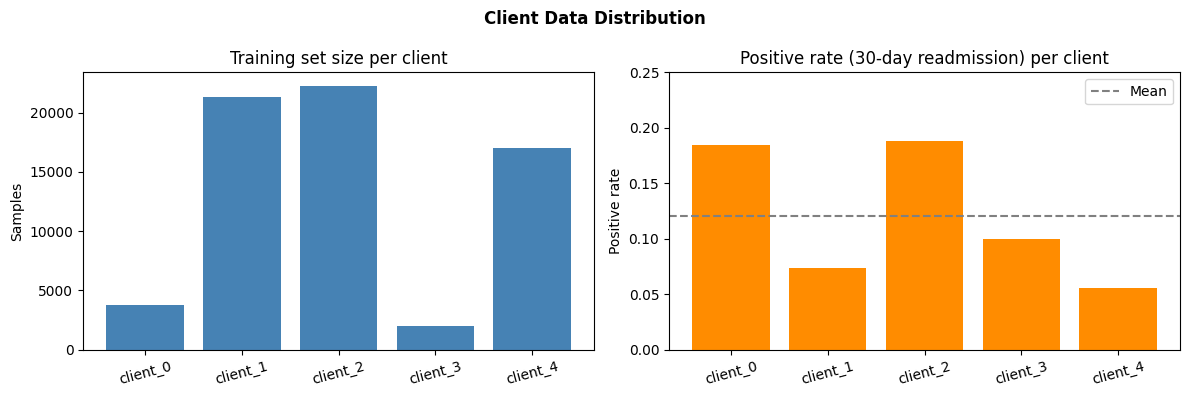


─────────────────────────────────────────────────────────────────
  α=1.0 client data summary:
  Client        Train      Val     Test   Features  Pos. rate
  ────────── ──────── ──────── ──────── ────────── ──────────
  client_0     21,064    3,655    6,157         99      0.121
  client_1     27,677    4,916    8,226         99      0.035
  client_2      3,855      746    1,189         99      0.160
  client_3      5,566      985    1,664         99      0.231
  client_4      8,208    1,546    2,371         99      0.256


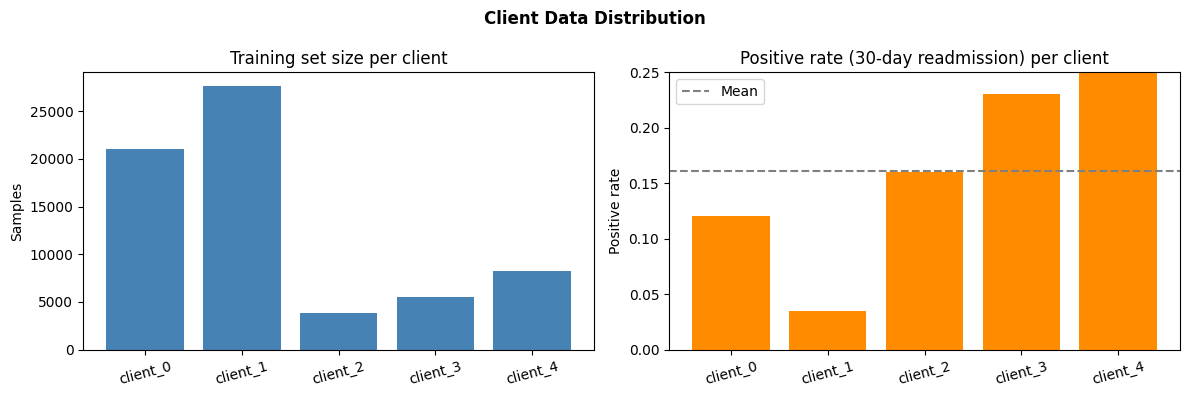


─────────────────────────────────────────────────────────────────
  α=5.0 client data summary:
  Client        Train      Val     Test   Features  Pos. rate
  ────────── ──────── ──────── ──────── ────────── ──────────
  client_0     19,258    3,385    5,686         99      0.075
  client_1     12,850    2,237    3,714         99      0.130
  client_2      6,047    1,078    1,807         99      0.068
  client_3     14,960    2,624    4,371         99      0.236
  client_4     13,463    2,336    4,009         99      0.042


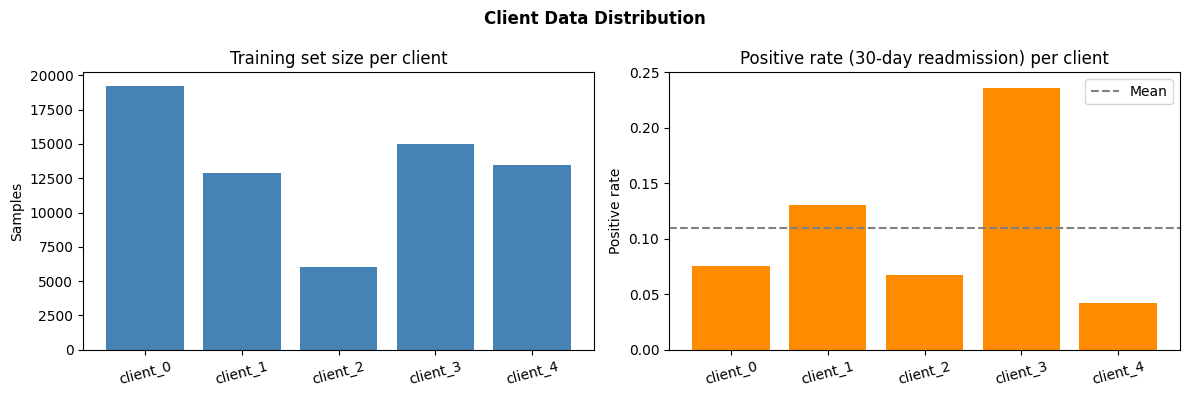

In [40]:
for alpha in ALPHA_SWEEP: 

    print(f'\n{"─" * 65}')
    print(f'  α={alpha} client data summary:')
    print(f'  {"Client":<10} {"Train":>8} {"Val":>8} {"Test":>8} {"Features":>10} {"Pos. rate":>10}')
    print(f'  {"─"*10} {"─"*8} {"─"*8} {"─"*8} {"─"*10} {"─"*10}')
    client_info = {}

    for i in range(N_CLIENTS):
        client_dir = os.path.join(OUTPUT_DIR, f'alpha_{alpha}', f'client_{i}')
        with open(os.path.join(client_dir, 'client_info.json'), 'r') as f:
            client_info[f'client_{i}'] = json.load(f)
            

    for k, v in client_info.items():
        print(f'  {k:<10} {v["n_train"]:>8,} {v["n_val"]:>8,} '
            f'{v["n_test"]:>8,} {v["n_features"]:>10,} {v["positive_rate"]:>10.3f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('Client Data Distribution', fontweight='bold')

    clients_keys     = list(client_info.keys())
    train_sizes = [client_info[c]['n_train'] for c in clients_keys]
    pos_rates   = [client_info[c]['positive_rate'] for c in clients_keys]

    axes[0].bar(clients_keys, train_sizes, color='steelblue')
    axes[0].set_title('Training set size per client')
    axes[0].set_ylabel('Samples')
    axes[0].tick_params(axis='x', rotation=15)

    axes[1].bar(clients_keys, pos_rates, color='darkorange')
    axes[1].axhline(sum(pos_rates) / len(pos_rates), color='gray',
                    linestyle='--', label='Mean')
    axes[1].set_title('Positive rate (30-day readmission) per client')
    axes[1].set_ylabel('Positive rate')
    axes[1].set_ylim(0, 0.25)
    axes[1].tick_params(axis='x', rotation=15)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'client_distribution.png'), dpi=150, bbox_inches='tight')
    plt.show()

## Model Setup

In [30]:
# LayerNorm is more stable than BatchNorm for small/heterogeneous FL batches.
# Split into feature_extractor + predictor to support partial sharing variant.
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, output_dim=2, dropout=0.3):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.LayerNorm(hidden_dim // 4), nn.ReLU(), nn.Dropout(dropout),
        )
        self.predictor = nn.Linear(hidden_dim // 4, output_dim)

    def forward(self, x):
        return self.predictor(self.feature_extractor(x))

    def encode(self, x):
        return self.feature_extractor(x)


In [36]:
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Tuning setup ──────────────────────────────────────────────────────────────
# Use alpha=1.0, seed=42, client_0 as the tuning client.
# alpha=1.0 is the most balanced partition — representative without being
# pathological. We tune on a single client to preserve the federated assumption
# that no central data access is available during configuration.
_TUNE_ALPHA  = 1.0
_TUNE_SEED   = 42
_TUNE_CLIENT = 0
_TUNE_EPOCHS = 50

_d = os.path.join(OUTPUT_DIR, f'alpha_{_TUNE_ALPHA}', f'client_{_TUNE_CLIENT}')
_X_tr = torch.tensor(np.load(f'{_d}/X_train.npy'), dtype=torch.float32)
_y_tr = torch.tensor(np.load(f'{_d}/y_train.npy'), dtype=torch.long)
_X_va = torch.tensor(np.load(f'{_d}/X_val.npy'),   dtype=torch.float32)
_y_va = torch.tensor(np.load(f'{_d}/y_val.npy'),   dtype=torch.long)
_input_dim = _X_tr.shape[1]

reoptimal_search = False

# Smallest client train size across all alphas — used to cap batch_size
_min_client_size = min(
    json.load(open(os.path.join(OUTPUT_DIR, f'alpha_{a}', f'client_{i}',
                                'client_info.json')))['n_train']
    for a in ALPHA_SWEEP for i in range(N_CLIENTS)
)
print(f'Minimum client train size across all partitions: {_min_client_size:,}')
print(f'Tuning on: alpha={_TUNE_ALPHA}, client_{_TUNE_CLIENT}, '
      f'{len(_X_tr):,} train samples')


def _fl_objective(trial):
    hidden_dim = trial.suggest_categorical('hidden_dim', [128, 256, 512])
    dropout    = trial.suggest_float('dropout', 0.1, 0.5)
    lr         = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    # Cap batch_size to avoid exceeding the smallest client's training set.
    # With drop_last=True a batch_size > n_train means zero updates per epoch.
    max_bs = min(256, _min_client_size)
    batch_size = trial.suggest_categorical(
        'batch_size', [b for b in [64, 128, 256] if b <= max_bs]
    )

    torch.manual_seed(_TUNE_SEED)
    model_t = MLP(_input_dim, hidden_dim=hidden_dim, dropout=dropout).to(device)
    loader_t = DataLoader(
        TensorDataset(_X_tr, _y_tr),
        batch_size=batch_size, shuffle=True, drop_last=True
    )
    cw = compute_class_weight('balanced',
                              classes=np.unique(_y_tr.numpy()),
                              y=_y_tr.numpy())
    criterion_t = nn.CrossEntropyLoss(
        weight=torch.tensor(cw, dtype=torch.float32).to(device)
    )
    optimizer_t = torch.optim.Adam(model_t.parameters(), lr=lr)

    best_auc = 0.0
    for epoch in range(_TUNE_EPOCHS):
        model_t.train()
        for xb, yb in loader_t:
            xb, yb = xb.to(device), yb.to(device)
            optimizer_t.zero_grad()
            criterion_t(model_t(xb), yb).backward()
            optimizer_t.step()

        model_t.eval()
        with torch.no_grad():
            vp = torch.softmax(
                model_t(_X_va.to(device)), dim=1
            )[:, 1].cpu().numpy()

        if len(np.unique(_y_va.numpy())) > 1:
            auc = roc_auc_score(_y_va.numpy(), vp)
            best_auc = max(best_auc, auc)
            trial.report(auc, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    return best_auc

if reoptimal_search:
    _study = optuna.create_study(
        direction='maximize',
        sampler=TPESampler(seed=_TUNE_SEED),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
    )
    _study.optimize(_fl_objective, n_trials=40, show_progress_bar=True)

    # Save for future runs
    _hp_save_path = os.path.join(OUTPUT_DIR, 'fl_hyperparams.json')
    with open(_hp_save_path, 'w') as f:
        json.dump({
            'best_params': _study.best_params,
            'best_value':  _study.best_value,
        }, f, indent=2)
    print(f'Hyperparameters saved → {_hp_save_path}')

else:
    _hp_save_path = os.path.join(OUTPUT_DIR, 'fl_hyperparams.json')
    if not os.path.exists(_hp_save_path):
        raise FileNotFoundError(
            f'No saved hyperparameters at {_hp_save_path}. '
            f'Set reoptimal_search=True to run the search.'
        )
    with open(_hp_save_path) as f:
        _saved = json.load(f)
    class _StudyProxy:
        best_params = {k: v for k, v in _saved.items() if k != 'best_value'}
        best_value  = _saved.get('best_value', float('nan'))
    _study = _StudyProxy()

print(f'\nBest federated AUC (single client, local training): {_study.best_value:.4f}')
print(f'Best params: {_study.best_params}')

Minimum client train size across all partitions: 2,004
Tuning on: alpha=1.0, client_0, 21,064 train samples

Best federated AUC (single client, local training): nan
Best params: {'hidden_dim': 512, 'dropout': 0.18032260117084994, 'lr': 0.009295988540171725, 'batch_size': 256}


In [ ]:
# ── Federated hyperparameters ─────────────────────────────────────────────────
# Sourced from the Optuna search above, tuned on a single client with the
# LayerNorm split architecture. Both FedAvg and FedGen use these values since
# they share the same MLP backbone.

_bp = _study.best_params

FL_ROUNDS    = 30
LOCAL_EPOCHS = 10
HIDDEN_DIM   = _bp['hidden_dim']
DROPOUT      = _bp['dropout']
LR           = _bp['lr']
BATCH_SIZE   = _bp['batch_size']
PATIENCE     = 5

print('Federated hyperparameters (tuned on single client, LayerNorm MLP):')
print(f'  hidden_dim : {HIDDEN_DIM}')
print(f'  dropout    : {DROPOUT:.4f}')
print(f'  lr         : {LR:.6f}')
print(f'  batch_size : {BATCH_SIZE}')
print(f'\nFL settings:')
print(f'  rounds     : {FL_ROUNDS}')
print(f'  local_epochs: {LOCAL_EPOCHS}')
print(f'  patience   : {PATIENCE}')

Federated hyperparameters (tuned on single client, LayerNorm MLP):
  hidden_dim : 512
  dropout    : 0.1803
  lr         : 0.009296
  batch_size : 256

FL settings:
  rounds     : 30
  local_epochs: 10
  patience   : 5


## FedAvg

In [ ]:
# ── Local training — full sharing (returns full state dict) ──────────────────
def local_train(model, X_train, y_train, X_val, y_val, epochs, batch_size):
    loader = DataLoader(TensorDataset(X_train, y_train),
                        batch_size=batch_size, shuffle=True, drop_last=True)
    classes = np.unique(y_train.numpy())
    cw = compute_class_weight('balanced', classes=classes, y=y_train.numpy())
    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(cw, dtype=torch.float32).to(device)
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    best_val_auc = 0.0
    best_state   = {k: v.clone() for k, v in model.state_dict().items()}

    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            vp = torch.softmax(model(X_val.to(device)), dim=1)[:, 1].cpu().numpy()
        if len(np.unique(y_val.numpy())) > 1:
            auc = roc_auc_score(y_val.numpy(), vp)
            if auc > best_val_auc:
                best_val_auc = auc
                best_state = {k: v.clone() for k, v in model.state_dict().items()}

    return best_state, len(X_train)



# ── Local training — partial sharing (only predictor aggregated) ──────────────
def local_train_partial(model, X_train, y_train, X_val, y_val, epochs, batch_size):
    """Feature extractor stays local; only predictor state dict is returned."""
    loader = DataLoader(TensorDataset(X_train, y_train),
                        batch_size=batch_size, shuffle=True, drop_last=True)
    classes = np.unique(y_train.numpy())
    cw = compute_class_weight('balanced', classes=classes, y=y_train.numpy())
    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(cw, dtype=torch.float32).to(device)
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    best_val_auc   = 0.0
    best_pred_state = {k: v.clone() for k, v in model.predictor.state_dict().items()}

    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            vp = torch.softmax(model(X_val.to(device)), dim=1)[:, 1].cpu().numpy()
        if len(np.unique(y_val.numpy())) > 1:
            auc = roc_auc_score(y_val.numpy(), vp)
            if auc > best_val_auc:
                best_val_auc = auc
                best_pred_state = {k: v.clone()
                                   for k, v in model.predictor.state_dict().items()}

    return best_pred_state, len(X_train)


# ── FedAvg aggregation (works for full state dict or predictor-only dict) ─────
def fed_avg(state_dicts, sample_counts):
    total = sum(sample_counts)
    return {
        key: sum(sd[key] * (sample_counts[i] / total)
                 for i, sd in enumerate(state_dicts))
        for key in state_dicts[0].keys()
    }


print('Training functions defined.')


Training functions defined.


In [ ]:
# ── Helper: load client tensors for one alpha ─────────────────────────────────

re_train = True

def load_clients_for_alpha(alpha):
    clients = {}
    for i in range(N_CLIENTS):
        d = os.path.join(OUTPUT_DIR, f'alpha_{alpha}', f'client_{i}')
        clients[i] = {
            'X_train': torch.tensor(np.load(f'{d}/X_train.npy'), dtype=torch.float32),
            'y_train': torch.tensor(np.load(f'{d}/y_train.npy'), dtype=torch.long),
            'X_val'  : torch.tensor(np.load(f'{d}/X_val.npy'),   dtype=torch.float32),
            'y_val'  : torch.tensor(np.load(f'{d}/y_val.npy'),   dtype=torch.long),
            'X_test' : torch.tensor(np.load(f'{d}/X_test.npy'),  dtype=torch.float32),
            'y_test' : torch.tensor(np.load(f'{d}/y_test.npy'),  dtype=torch.long),
        }
    return clients


# ── Helper: evaluate global model, return (global_auc, per_client_dict) ───────
def evaluate_global(model, clients, use_local_encoders=False, local_models=None):
    model.eval()
    all_proba, all_y = [], []
    per_client = {}
    with torch.no_grad():
        for i, c in clients.items():
            enc = local_models[i] if use_local_encoders else model
            z = enc.encode(c['X_test'].to(device))
            proba = torch.softmax(model.predictor(z), dim=1)[:, 1].cpu().numpy()
            y_test = c['y_test'].numpy()
            all_proba.append(proba)
            all_y.append(y_test)
            if len(np.unique(y_test)) > 1:
                per_client[str(i)] = float(roc_auc_score(y_test, proba))
    return float(roc_auc_score(np.concatenate(all_y), np.concatenate(all_proba))), per_client


# ── Full sharing federation loop ───────────────────────────────────────────────
def run_fedavg_full(clients, input_dim, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = MLP(input_dim=input_dim, hidden_dim=HIDDEN_DIM, dropout=DROPOUT).to(device)
    # Upload (client→server) + download (server→client), float32 = 4 bytes
    n_params = sum(p.numel() for p in model.parameters())
    bytes_per_round = 2 * n_params * 4 * N_CLIENTS
    best_val_auc, best_state, no_improve = 0.0, None, 0
    history, cumul_mb, total_bytes = [], [], 0

    for fl_round in range(FL_ROUNDS):
        state_dicts, counts = [], []
        for i in range(N_CLIENTS):
            local = MLP(input_dim=input_dim, hidden_dim=HIDDEN_DIM, dropout=DROPOUT).to(device)
            local.load_state_dict(model.state_dict())
            sd, n = local_train(local, clients[i]['X_train'], clients[i]['y_train'],
                                clients[i]['X_val'],   clients[i]['y_val'],
                                LOCAL_EPOCHS, BATCH_SIZE)
            state_dicts.append(sd)
            counts.append(n)
        model.load_state_dict(fed_avg(state_dicts, counts))
        total_bytes += bytes_per_round

        model.eval()
        vp, vy, tp, ty = [], [], [], []
        with torch.no_grad():
            for i in range(N_CLIENTS):
                vp.append(torch.softmax(model(clients[i]['X_val'].to(device)), dim=1)[:,1].cpu().numpy())
                vy.append(clients[i]['y_val'].numpy())
                tp.append(torch.softmax(model(clients[i]['X_test'].to(device)), dim=1)[:,1].cpu().numpy())
                ty.append(clients[i]['y_test'].numpy())
        val_auc  = roc_auc_score(np.concatenate(vy), np.concatenate(vp))
        test_auc = roc_auc_score(np.concatenate(ty), np.concatenate(tp))
        history.append({'val': val_auc, 'test': test_auc})
        cumul_mb.append(total_bytes / (1024**2))
        print(f'  [full] R{fl_round+1}: val={val_auc:.4f} test={test_auc:.4f} '
              f'cumul={cumul_mb[-1]:.2f}MB')

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f'  Early stopping at round {fl_round+1}.')
                break

    model.load_state_dict(best_state)
    global_auc, per_client = evaluate_global(model, clients)
    return global_auc, per_client, history, cumul_mb


# ── Partial sharing federation loop ───────────────────────────────────────────
def run_fedavg_partial(clients, input_dim, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = MLP(input_dim=input_dim, hidden_dim=HIDDEN_DIM, dropout=DROPOUT).to(device)
    local_models = {
        i: MLP(input_dim=input_dim, hidden_dim=HIDDEN_DIM, dropout=DROPOUT).to(device)
        for i in range(N_CLIENTS)
    }
    for i in range(N_CLIENTS):
        local_models[i].load_state_dict(model.state_dict())
    n_params_pred = sum(p.numel() for p in model.predictor.parameters())
    bytes_per_round = 2 * n_params_pred * 4 * N_CLIENTS
    best_val_auc, best_pred_state, no_improve = 0.0, None, 0
    history, cumul_mb, total_bytes = [], [], 0

    for fl_round in range(FL_ROUNDS):
        pred_states, counts = [], []
        for i in range(N_CLIENTS):
            local_models[i].predictor.load_state_dict(model.predictor.state_dict())
            sd, n = local_train_partial(
                local_models[i], clients[i]['X_train'], clients[i]['y_train'],
                clients[i]['X_val'], clients[i]['y_val'], LOCAL_EPOCHS, BATCH_SIZE
            )
            pred_states.append(sd)
            counts.append(n)
        model.predictor.load_state_dict(fed_avg(pred_states, counts))
        total_bytes += bytes_per_round

        model.eval()
        vp, vy, tp, ty = [], [], [], []
        with torch.no_grad():
            for i in range(N_CLIENTS):
                z_v = local_models[i].encode(clients[i]['X_val'].to(device))
                z_t = local_models[i].encode(clients[i]['X_test'].to(device))
                vp.append(torch.softmax(model.predictor(z_v), dim=1)[:,1].cpu().numpy())
                vy.append(clients[i]['y_val'].numpy())
                tp.append(torch.softmax(model.predictor(z_t), dim=1)[:,1].cpu().numpy())
                ty.append(clients[i]['y_test'].numpy())
        val_auc  = roc_auc_score(np.concatenate(vy), np.concatenate(vp))
        test_auc = roc_auc_score(np.concatenate(ty), np.concatenate(tp))
        history.append({'val': val_auc, 'test': test_auc})
        cumul_mb.append(total_bytes / (1024**2))
        print(f'  [partial] R{fl_round+1}: val={val_auc:.4f} test={test_auc:.4f} '
              f'cumul={cumul_mb[-1]:.2f}MB')

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_pred_state = {k: v.clone() for k, v in model.predictor.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f'  Early stopping at round {fl_round+1}.')
                break

    model.predictor.load_state_dict(best_pred_state)
    global_auc, per_client = evaluate_global(model, clients,
                                             use_local_encoders=True,
                                             local_models=local_models)
    return global_auc, per_client, history, cumul_mb


# ── Save helper ────────────────────────────────────────────────────────────────
def save_result(alpha, seed, variant, test_auc, per_client, history, cumul_mb):
    result_dir = os.path.join('results', f'alpha_{alpha}', f'seed_{seed}')
    os.makedirs(result_dir, exist_ok=True)
    path = os.path.join(result_dir, f'{variant}.json')
    with open(path, 'w') as f:
        json.dump({'test_auc': test_auc, 'per_client': per_client,
                   'history': history, 'cumul_mb': cumul_mb}, f, indent=2)
    print(f'  Saved → {path}  (test_auc={test_auc:.4f})')


# ── Outer sweep: all alphas × all seeds ───────────────────────────────────────
for alpha in ALPHA_SWEEP:
    for seed in SEEDS:
        r_dir = os.path.join('results', f'alpha_{alpha}', f'seed_{seed}')
        full_path    = os.path.join(r_dir, 'fedavg_full.json')
        partial_path = os.path.join(r_dir, 'fedavg_partial.json')

        if os.path.exists(full_path) and os.path.exists(partial_path) and not re_train:
            print(f'α={alpha} seed={seed}: already done, skipping.')
            continue

        print(f'\n{"="*60}')
        print(f'FedAvg  α={alpha}  seed={seed}')
        print(f'{"="*60}')

        clients = load_clients_for_alpha(alpha)
        input_dim = clients[0]['X_train'].shape[1]

        if not os.path.exists(full_path) or re_train:
            print('\n--- fedavg_full ---')
            auc, pc, hist, cmb = run_fedavg_full(clients, input_dim, seed)
            save_result(alpha, seed, 'fedavg_full', auc, pc, hist, cmb)

        if not os.path.exists(partial_path) or re_train:
            print('\n--- fedavg_partial ---')
            auc, pc, hist, cmb = run_fedavg_partial(clients, input_dim, seed)
            save_result(alpha, seed, 'fedavg_partial', auc, pc, hist, cmb)

print('\nAll FedAvg experiments complete.')



FedAvg  α=0.5  seed=42

--- fedavg_full ---
  [full] R1: val=0.6319 test=0.6202 cumul=8.30MB
  [full] R2: val=0.6359 test=0.6212 cumul=16.59MB
  [full] R3: val=0.6323 test=0.6181 cumul=24.89MB
  [full] R4: val=0.6328 test=0.6209 cumul=33.18MB
  [full] R5: val=0.6310 test=0.6149 cumul=41.48MB
  [full] R6: val=0.6289 test=0.6148 cumul=49.78MB
  [full] R7: val=0.6329 test=0.6130 cumul=58.07MB
  Early stopping at round 7.
  Saved → results/alpha_0.5/seed_42/fedavg_full.json  (test_auc=0.6212)

--- fedavg_partial ---
  [partial] R1: val=0.6091 test=0.5940 cumul=0.01MB
  [partial] R2: val=0.6854 test=0.6685 cumul=0.02MB
  [partial] R3: val=0.6954 test=0.6767 cumul=0.03MB
  [partial] R4: val=0.6920 test=0.6788 cumul=0.04MB
  [partial] R5: val=0.6772 test=0.6557 cumul=0.05MB
  [partial] R6: val=0.6898 test=0.6699 cumul=0.06MB
  [partial] R7: val=0.6931 test=0.6857 cumul=0.07MB
  [partial] R8: val=0.6697 test=0.6562 cumul=0.08MB
  Early stopping at round 8.
  Saved → results/alpha_0.5/seed_42/

In [ ]:
# ── Summary: print saved results ─────────────────────────────────────────────
import glob
print(f'{"Alpha":>6}  {"Seed":>6}  {"Variant":<20}  {"Test AUC":>9}  {"Rounds":>7}')
print('-' * 60)
for path in sorted(glob.glob('results/alpha_*/seed_*/*.json')):
    r = json.load(open(path))
    parts = path.replace('results/', '').replace('.json', '').split('/')
    alpha_s, seed_s, variant = parts
    print(f'{alpha_s.replace("alpha_",""):>6}  '
          f'{seed_s.replace("seed_",""):>6}  '
          f'{variant:<20}  '
          f'{r["test_auc"]:>9.4f}  '
          f'{len(r["history"]):>7}')


 Alpha    Seed  Variant                Test AUC   Rounds
------------------------------------------------------------
   0.5     123  fedavg_full              0.6162        7
   0.5     123  fedavg_partial           0.6369        8
   0.5      42  fedavg_full              0.6212        7
   0.5      42  fedavg_partial           0.6734        8
   0.5       7  fedavg_full              0.6213        6
   0.5       7  fedavg_partial           0.6570        8
   1.0     123  fedavg_full              0.6172        8
   1.0     123  fedavg_partial           0.6096       12
   1.0      42  fedavg_full              0.6165        7
   1.0      42  fedavg_partial           0.6142        6
   1.0       7  fedavg_full              0.6111        8
   1.0       7  fedavg_partial           0.6178       15
   5.0     123  fedavg_full              0.6387       11
   5.0     123  fedavg_partial           0.5914       11
   5.0      42  fedavg_full              0.6387       15
   5.0      42  fedavg_part

In [ ]:
# Results are now saved automatically inside the sweep loop above.
# Run this cell to reload and inspect a specific result:
# r = json.load(open('results/alpha_0.5/seed_42/fedavg_full.json'))
# print(r['test_auc'], len(r['history']), len(r['cumul_mb']))
